# SKR vs Distance: Finite BB84 vs `bb84_server_client`

This notebook compares the final secret key rate (SKR) versus fiber distance for two BB84 implementations:

- **Finite BB84** from `bb84_finite.py`.
- **Server-client BB84** from `ServerClientBB84/bb84_server_client.py`, using the final key after error correction and privacy amplification.

To keep the comparison simple, both cases use the same shared physical parameters where possible. The server-client simulation is wired directly from channel to detector so it stays close to the finite BB84 model and does not include Eve.

In [1]:
import asyncio
import contextlib
import io
import os
import sys

import nest_asyncio
import matplotlib.pyplot as plt
import numpy as np

nest_asyncio.apply()

import time
from ServerClientBB84.bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, APIClient
from bb84_finite import Source, Channel, Detector as FiniteDetector, Protocol
from simBB84 import BB84Simulator as BB84_Asymptotic

# Ensure we can import from the ServerClientBB84 directory
current_dir = os.getcwd()
target_dir = os.path.join(current_dir, 'ServerClientBB84')
if target_dir not in sys.path:
    sys.path.append(target_dir)

try:
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient
except ImportError:
    sys.path.append(os.getcwd())
    from bb84_server_client import AliceServer, BobClient, QuantumChannel, Detector, Eve, APIClient

def run_async(coro):
    try:
        loop = asyncio.get_event_loop()
    except RuntimeError:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
    return loop.run_until_complete(coro)

print('Imports ready.')

[NR-LDPC] GPU Detected: 1 device(s). Acceleration ENABLED.
[NR-LDPC] Sionna Library Loaded Successfully.
Imports ready.


In [2]:
# Shared parameters
distance_km = np.linspace(0, 100, 10)
source_freq_hz = 1e6
block_size = int(1e6)
mean_photon_num = 0.1
alignment_error = 0.001
fiber_loss_db_km = 0.2
detector_efficiency = 0.8
dark_count_rate = 1e4
time_window = 1e-9
optical_error_rate = 0.01
dark_count_prob = 1 - np.exp(-dark_count_rate * time_window)

print('Common parameters:')
print(f'  Distances (km): {distance_km.tolist()}')
print(f'  Source frequency (Hz): {source_freq_hz:.2e}')
print(f'  Block size / emitted qubits: {block_size}')
print(f'  Fiber loss (dB/km): {fiber_loss_db_km}')
print(f'  Detector efficiency: {detector_efficiency}')
print(f'  Dark count probability: {dark_count_prob:.3e}')
print(f'  Optical error rate: {optical_error_rate}')

Common parameters:
  Distances (km): [0.0, 11.11111111111111, 22.22222222222222, 33.33333333333333, 44.44444444444444, 55.55555555555556, 66.66666666666666, 77.77777777777777, 88.88888888888889, 100.0]
  Source frequency (Hz): 1.00e+06
  Block size / emitted qubits: 1000000
  Fiber loss (dB/km): 0.2
  Detector efficiency: 0.8
  Dark count probability: 1.000e-05
  Optical error rate: 0.01


In [3]:
# Finite BB84 SKR vs distance
finite_source = Source(
    freq=source_freq_hz,
    mean_photon_num=mean_photon_num,
    q=1.0,
    alignment_error=alignment_error,
)
finite_channel = Channel(
    length_km=0.0,
    att_db_km=fiber_loss_db_km,
    channel_mode='fiber',
)
finite_detector = FiniteDetector(
    efficiency=detector_efficiency,
    dark_count_rate=dark_count_rate,
    time_window=time_window,
)
finite_protocol = Protocol(
    finite_source,
    finite_channel,
    finite_detector,
    epsilon_sec=1e-9,
    epsilon_cor=1e-9, 
    f_ec=1.16
)

finite_skr = finite_protocol.skr_vs_distance(distance_km, block_size)

# Asymptotic BB84 SKR vs distance
asym_bb84 = BB84_Asymptotic(
    mu=mean_photon_num,
    detector_efficiency=detector_efficiency,
    channel_base_efficiency=1.0,
    dark_count_rate=dark_count_rate,
    time_window=time_window,
    attenuation=fiber_loss_db_km,
    channel_mode='fiber',
    ec_eff_factor=1.16,
    misalignment_base=0.015,
    misalignment_factor=0.0004,
)

asym_skr_dist = []
for d in distance_km:
    asym_bb84.update_distance(d)
    asym_bb84.update_mu(mean_photon_num)
    # asym_bb84.repetition_rate = source_freq_hz
    raw_rate = asym_bb84.calculate_skr()
    asym_skr_dist.append(max(1e-12, raw_rate))

print('Finite and Asymptotic BB84 SKR computed.')

Finite and Asymptotic BB84 SKR computed.


In [4]:

protocols = ['cascade', 'winnow', 'polar', 'nr_ldpc_std', 'ldpc_rateadaptive']
oop_skr_all = {p: [] for p in protocols}

print(f"Running Authentic OOP Actor Simulation (QuantumChannel + Detector)")
print(f"  Block size: {block_size}")
print(f"  Distances:  {distance_km.tolist()}")

async def run_oop_distance_point(length_km, protocol):
    # Instantiate authentic Original objects
    channel = QuantumChannel("Fiber", length_km, fiber_loss_db_km, optical_error_rate, next_actor=None)
    alice = AliceServer("Alice", channel, num_qubits=block_size, mu=mean_photon_num, verbose=False)
    api = APIClient(alice)
    
    # We use Toeplitz PA and Cascade
    bob = BobClient("Bob", api, protocol=protocol, pa_protocol="toeplitz", verbose=False)
    detector = Detector("Det", detector_efficiency, dark_count_prob, parent_bob=bob)
    
    # Complete Actor loop wiring
    channel.next_actor = detector
    
    # Start actors inside our loop
    actors = [alice, channel, detector, bob]
    tasks = [asyncio.create_task(a.start()) for a in actors]
    
    # 1. Quantum phase
    await alice.run_quantum_transmission()
    
    # Wait until all photon objects drain from queues
    while (not channel.mailbox.empty() or 
           not detector.mailbox.empty() or 
           not bob.mailbox.empty()):
        await asyncio.sleep(0.01)
    
    # Minute buffer for final detection handling
    await asyncio.sleep(0.05)
    
    # 2. Setup Classical Bounds dynamically
    T = channel.transmittance
    eta = detector.eta
    mu = alice.mu
    
    p_sig = 1.0 - np.exp(-mu * T * eta)
    p_dark = 2 * detector.p_dc
    p_click = p_sig + p_dark - (p_sig * p_dark)
    p_multi = 1.0 - (1.0 + mu) * np.exp(-mu)
    
    q1 = max(0.0, 1.0 - (p_multi / p_click)) if p_click > 0 else 0.0
    
    # 3. Post-Processing Phase directly via Bob object
    pa_length = 0
    try:
        results = await bob.run_classical_post_processing(alice.num_qubits, q1=q1)
        pa_length = results.get('pa_length', 0)
    except Exception as e:
        # Errors typically arise if Sifted key string is entirely exhausted due to extreme QBER
        pass
        
    # Teardown logic
    for a in actors:
        await a.send(a, ("STOP",))
    for t in tasks:
        t.cancel()
        
    skr = (pa_length / block_size) * source_freq_hz if pa_length > 0 else 0.0
    return skr

async def execute_oop_sweep():
    t0 = time.time()
    for p in protocols:
        print(f"\n--- Running sweep for protocol: {p} ---")
        for d in distance_km:
            skr = await run_oop_distance_point(d, p)
            oop_skr_all[p].append(skr)
            print(f"Distance {d:>5.1f} km [{p}] -> Authentic OOP SKR = {skr:.3e} bits/s")
    print(f"OOP Sweep completed in {time.time() - t0:.2f}s.")

# We run this single-threaded in the Jupyter event loop (allowed via nest_asyncio)
run_async(execute_oop_sweep())

Running Authentic OOP Actor Simulation (QuantumChannel + Detector)
  Block size: 1000000
  Distances:  [0.0, 11.11111111111111, 22.22222222222222, 33.33333333333333, 44.44444444444444, 55.55555555555556, 66.66666666666666, 77.77777777777777, 88.88888888888889, 100.0]

--- Running sweep for protocol: cascade ---

[BOB] Processing 76443 detection events.
[BOB] First 15 Valid Detections: 0(+), 1(x), 0(x), 1(+), 0(x), 0(+), 1(x), 0(x), 0(x), 0(x), 1(+), 0(x), 0(+), 1(+), 1(x) ...
[BOB] Sending 76443 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 38200 events.
[BOB] Sifted Key Preview: [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0]...
[BOB] Sampling 7640 bits for QBER estimation...
[BOB] QBER Analysis: 79 errors in 7640 samples. Estimated QBER = 1.03%
[BOB] Discarding revealed bits. Working Key Size: 30560
[BOB] Initializing Cascade Protocol...

[BOB] Starting Privacy Amplification using toeplitz...

      PRIVACY AMPLIFICATION METRICS
 [+] Reconciled K

I0000 00:00:1779603242.420032   20592 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4748 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5



[BOB] Starting Privacy Amplification using toeplitz...

      PRIVACY AMPLIFICATION METRICS
 [+] Reconciled Key Length (N):      30704 bits
 [+] QBER (e):                       1.0813%
 [+] Est. Eve's Knowledge Bound (t): 7981 bits
 [+] Security Parameter (S):         10 bits
 [+] Final Secret Key Length (R):    22713 bits
[BOB] Sent PA seed and protocol choice to Alice. Generated secret key of length 22713.
Distance   0.0 km [nr_ldpc_std] -> Authentic OOP SKR = 2.271e+04 bits/s

[BOB] Processing 47045 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(+), 0(x), 1(+), 1(+), 0(x), 0(+), 0(+), 0(+), 1(+), 1(+), 0(+), 0(+), 1(x), 1(+) ...
[BOB] Sending 47045 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 23711 events.
[BOB] Sifted Key Preview: [1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0]...
[BOB] Sampling 4742 bits for QBER estimation...
[BOB] QBER Analysis: 49 errors in 4742 samples. Estimated QBER = 1.03%
[BOB] Discarding revealed bits. W

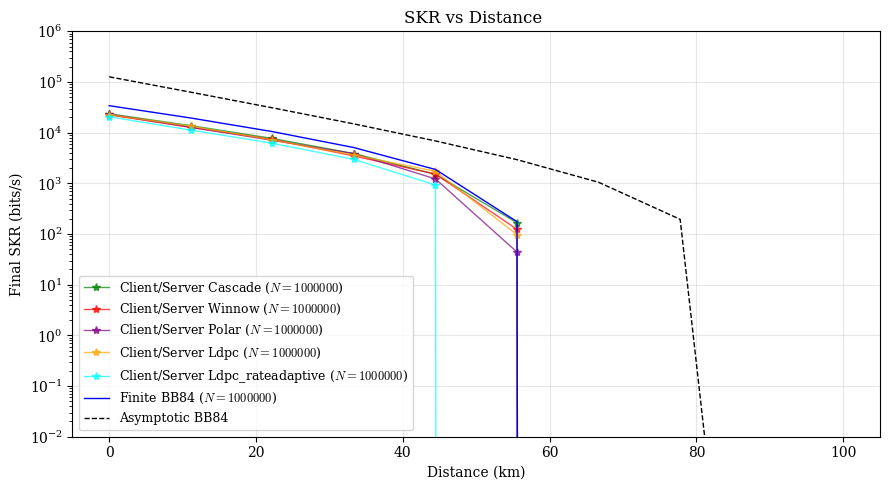

In [5]:
# Plotting the Authentic Full OOP Framework results
plt.figure(figsize=(9, 5))
colors = ['green', 'red', 'purple', 'orange', 'cyan']
alphas = [0.6, 0.5, 0.4, 0.3, 0.2]
for i, p in enumerate(protocols):
    label_name = 'Ldpc' if p == 'nr_ldpc_std' else p.capitalize()
    plt.semilogy(distance_km, oop_skr_all[p], '*-', linewidth=1, color=colors[i % len(colors)], alpha=0.7, label=f'Client/Server {label_name} ($N={block_size}$)')

# Bring down the subset of the original math finite skr for comparison in the same region
local_finite_skr = finite_protocol.skr_vs_distance(distance_km, block_size)
plt.semilogy(distance_km, local_finite_skr, linewidth=1, color='blue', label=f'Finite BB84 ($N={block_size}$)')

# Add the asymptotic curve
plt.semilogy(distance_km, asym_skr_dist, 'k--', linewidth=1, label='Asymptotic BB84')

plt.xlabel('Distance (km)')
plt.ylabel('Final SKR (bits/s)')
plt.title(f'SKR vs Distance ')
plt.grid(alpha=0.3)
plt.ylim(1e-2, 1e6)
plt.legend(prop={'size': 9})
plt.tight_layout()
plt.show()

---
# SKR vs Mean Photon Number ($\mu$)
This section compares the Secret Key Rate (SKR) vs Mean Photon Number ($\mu$) for finite BB84 and Server-Client BB84, ensuring multiphoton PNS penalties are correctly applied.

In [6]:
# Physical Parameters for Mu sweep
dist_mu_km = 50.0

In [7]:
# 1. Finite BB84 Setup & Simulation
mu_values = np.linspace(0.01, 1, 20)

finite_source_mu = Source(freq=source_freq_hz, mean_photon_num=mean_photon_num, q=1.0, alignment_error=alignment_error)
finite_channel_mu = Channel(length_km=dist_mu_km, att_db_km=fiber_loss_db_km, channel_mode='fiber')
finite_detector_mu = FiniteDetector(efficiency=detector_efficiency, dark_count_rate=dark_count_rate, time_window=time_window)

finite_protocol_mu = Protocol(finite_source_mu, finite_channel_mu, finite_detector_mu, epsilon_sec=1e-9, epsilon_cor=1e-9,f_ec=1.16)
finite_skr_mu = finite_protocol_mu.skr_vs_mu(mu_values, block_size)

# Asymptotic BB84 SKR vs mu
asym_bb84_mu = BB84_Asymptotic(
    mu=mean_photon_num,
    detector_efficiency=detector_efficiency,
    channel_base_efficiency=1.0,
    dark_count_rate=dark_count_rate,
    time_window=time_window,
    attenuation=fiber_loss_db_km,
    channel_mode='fiber',
    ec_eff_factor=1.16,
    misalignment_base=0.025,
    misalignment_factor=0.0004,
)

asym_skr_mu_dist = []
for mu_val in mu_values:
    asym_bb84_mu.update_distance(dist_mu_km)
    asym_bb84_mu.update_mu(mu_val)
    #asym_bb84_mu.repetition_rate = source_freq_hz
    raw_rate = asym_bb84_mu.calculate_skr()
    asym_skr_mu_dist.append(max(1e-12, raw_rate))

print("Finite and Asymptotic BB84 simulation completed.")

Finite and Asymptotic BB84 simulation completed.


In [8]:
# 2. Server-Client BB84 Simulation Function (Authentic OOP)
protocols = ['cascade', 'winnow', 'polar', 'nr_ldpc_std', 'ldpc_rateadaptive']
server_skr_mu_all = {p: [] for p in protocols}

# For performance reasons with full object propagation, you may optionally want to reduce the block_size 
# locally here by setting a local variable like: local_block_size = int(1e5)
local_block_size = block_size

print(f"Running Authentic OOP Mu Sweep Simulation for block size {local_block_size}...")
t0 = time.time()

async def run_oop_mu_point(mu_val, protocol):
    # Instantiate authentic Original objects
    channel = QuantumChannel("Fiber", dist_mu_km, fiber_loss_db_km, optical_error_rate, next_actor=None)
    alice = AliceServer("Alice", channel, num_qubits=local_block_size, mu=mu_val, verbose=False)
    api = APIClient(alice)
    
    # Use Toeplitz PA and Cascade
    bob = BobClient("Bob", api, protocol=protocol, pa_protocol="toeplitz", verbose=False)
    detector = Detector("Det", detector_efficiency, dark_count_prob, parent_bob=bob)
    
    # Complete Actor loop wiring
    channel.next_actor = detector
    
    # Start actors inside our loop
    actors = [alice, channel, detector, bob]
    tasks = [asyncio.create_task(a.start()) for a in actors]
    
    # 1. Quantum phase
    await alice.run_quantum_transmission()
    
    # Wait until all photon objects drain from queues
    while (not channel.mailbox.empty() or 
           not detector.mailbox.empty() or 
           not bob.mailbox.empty()):
        await asyncio.sleep(0.01)
    
    # Minute buffer for final detection handling
    await asyncio.sleep(0.05)
    
    # 2. Setup Classical Bounds dynamically
    T = channel.transmittance
    eta = detector.eta
    
    p_sig = 1.0 - np.exp(-mu_val * T * eta)
    p_dark = 2 * detector.p_dc
    p_click = p_sig + p_dark - (p_sig * p_dark)
    p_multi = 1.0 - (1.0 + mu_val) * np.exp(-mu_val)
    
    # PNS bound
    q1 = max(0.0, 1.0 - (p_multi / p_click)) if p_click > 0 else 0.0
    
    # 3. Post-Processing Phase directly via Bob object
    pa_length = 0
    try:
        results = await bob.run_classical_post_processing(alice.num_qubits, q1=q1)
        pa_length = results.get('pa_length', 0)
    except Exception as e:
        # Fails generally due to large structural QBER discarding entire key
        pass
        
    # Teardown logic
    for a in actors:
        await a.send(a, ("STOP",))
    for t in tasks:
        t.cancel()
        
    skr = (pa_length / local_block_size) * source_freq_hz if pa_length > 0 else 0.0
    return skr

async def execute_oop_mu_sweep():
    for p in protocols:
        print(f"\n--- Running Mu sweep for protocol: {p} ---")
        for mu_val in mu_values:
            skr = await run_oop_mu_point(mu_val, p)
            server_skr_mu_all[p].append(skr)
            print(f"Mu: {mu_val:>4.2f} [{p}] -> Authentic OOP SKR = {skr:.3e} bits/s")

# Run via nest_asyncio event loop
run_async(execute_oop_mu_sweep())

print(f"Mu sweep finished in {time.time() - t0:.2f}s.")

Running Authentic OOP Mu Sweep Simulation for block size 1000000...

--- Running Mu sweep for protocol: cascade ---

[BOB] Processing 806 detection events.
[BOB] First 15 Valid Detections: 1(+), 1(+), 1(x), 0(+), 1(+), 1(x), 0(x), 1(+), 1(+), 1(x), 1(+), 0(x), 0(x), 1(+), 0(x) ...
[BOB] Sending 806 bases to Alice for sifting...
[BOB] Sifting complete. Bases matched on 407 events.
[BOB] Sifted Key Preview: [1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]...
[BOB] Sampling 81 bits for QBER estimation...
[BOB] QBER Analysis: 2 errors in 81 samples. Estimated QBER = 2.47%
[BOB] Discarding revealed bits. Working Key Size: 326
[BOB] Initializing Cascade Protocol...

[BOB] Starting Privacy Amplification using toeplitz...

      PRIVACY AMPLIFICATION METRICS
 [+] Reconciled Key Length (N):      326 bits
 [+] QBER (e):                       2.4691%
 [+] Est. Eve's Knowledge Bound (t): 120 bits
 [+] Security Parameter (S):         10 bits
 [+] Final Secret Key Length (R):    196 bits

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20592/3524802195.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Mean Photon Number ($\mu$)')
/tmp/ipykernel_20592/3524802195.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'SKR vs $\mu$ at {dist_mu_km} km')


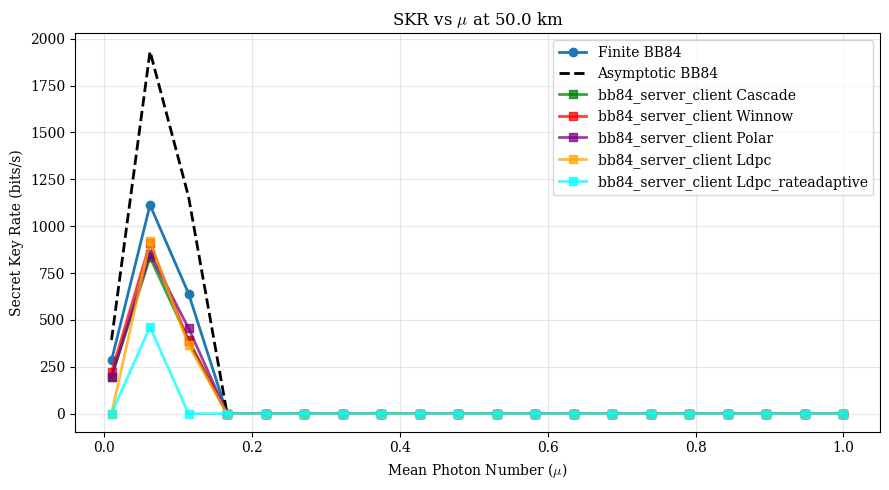

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(mu_values, finite_skr_mu, 'o-', linewidth=2, label='Finite BB84')

# Add asymptotic curve
plt.plot(mu_values, asym_skr_mu_dist, 'k--', linewidth=2, label='Asymptotic BB84')

colors = ['green', 'red', 'purple', 'orange', 'cyan']
for i, p in enumerate(protocols):
    label_name = 'Ldpc' if p == 'nr_ldpc_std' else p.capitalize()
    plt.plot(mu_values, server_skr_mu_all[p], 's-', linewidth=2, color=colors[i % len(colors)], label=f'bb84_server_client {label_name}', alpha=0.75)
plt.xlabel('Mean Photon Number ($\mu$)')
plt.ylabel('Secret Key Rate (bits/s)')
plt.title(f'SKR vs $\mu$ at {dist_mu_km} km')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()